In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [6]:
normal_label = 0
anomaly_label = 1

In [ ]:
def train_autoencoder():
    print("1. Loading pre-scaled raw data...")
    # This data is now perfectly normalized per-patient
    X = np.load('X_data_ALL.npy')  # Shape: (Windows, 256, Features)
    y = np.load('y_data_ALL.npy')  # Shape: (Windows,)

    # --- Step 1: Filter for Normal Data ---
    # We train ONLY on Baseline (1) and Meditation (4)
    normal_indices = np.isin(y, [1, 4]) 
    X_normal = X[normal_indices]
    
    # --- Step 2: Split Data ---
    X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)
    
    print(f"Training on {len(X_train)} windows.")
    print(f"Validating on {len(X_val)} windows.")

    # Note: Step 3 (Scaling) was removed because it was handled in preprocessing!

    # --- Step 3: Define Model ---
    input_shape = (X_train.shape[1], X_train.shape[2]) 

    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Encoder: Compress down
        layers.GRU(16, return_sequences=True), 
        layers.GRU(8, return_sequences=False), # Bottleneck
        
        # Bridge: Expand back to time
        layers.RepeatVector(input_shape[0]),
        
        # Decoder: Reconstruct up
        layers.GRU(8, return_sequences=True),
        layers.GRU(16, return_sequences=True),
        
        # Output: Reconstruct features
        layers.TimeDistributed(layers.Dense(input_shape[1])) 
    ])

    model.compile(optimizer='adam', loss='mae')
    model.summary()

    # --- Step 4: Train ---
    history = model.fit(
        X_train, X_train,  # Input = Target
        validation_data=(X_val, X_val),
        epochs=10,             
        batch_size=64,
        shuffle=True,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        ]
    )

    model.save('gru_autoencoder.h5')
    print("Model has been trained and saved as 'gru_autoencoder.h5'.")

    # --- Visualization ---
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MAE)')
    plt.legend()
    plt.show()

1. Loading pre-scaled raw data...
Training on 11448 windows.
Validating on 2862 windows.
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_4 (GRU)                 (None, 256, 16)           1152      
                                                                 
 gru_5 (GRU)                 (None, 4)                 264       
                                                                 
 repeat_vector_1 (RepeatVect  (None, 256, 4)           0         
 or)                                                             
                                                                 
 gru_6 (GRU)                 (None, 256, 4)            120       
                                                                 
 gru_7 (GRU)                 (None, 256, 16)           1056      
                                                                 
 time_distributed_1 (TimeDis  (

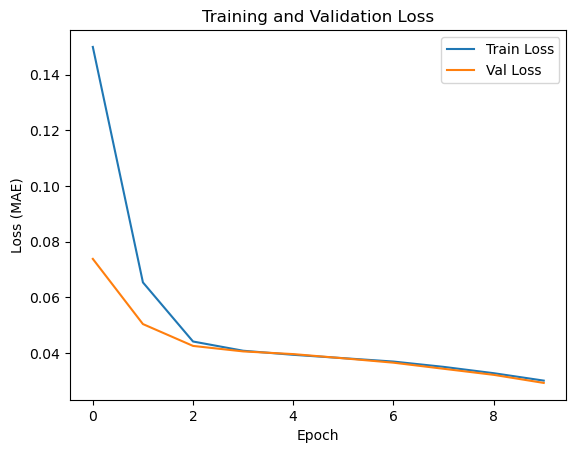

In [8]:
if __name__ == "__main__":
    train_autoencoder()